### Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

In [3]:
WORKING_DIR = Path('/content/drive/MyDrive/aiOCR')
WORKING_DIR.mkdir(exist_ok=True)
IMAGES_DIR = Path(WORKING_DIR, 'images')
IMAGES_DIR.mkdir(exist_ok=True)
PDF_DIR = Path(WORKING_DIR, 'PDF')
PDF_DIR.mkdir(exist_ok=True)
OCR_DIR = Path(WORKING_DIR, 'OCR')
OCR_DIR.mkdir(exist_ok=True)

## Transform PDF to images

In [4]:
!pip install --no-deps -q bitsandbytes PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 71.8 MB/s eta 0:00:00:00:0100:01


In [5]:
import fitz

In [6]:
def convert_pdf_to_images(pdf_path, dpi=300, limit=None, output_img_dir=None):

    pdf_path = Path(pdf_path)
    try:
        doc = fitz.open(pdf_path)
        for i, page_number in enumerate(range(len(doc))):
            page = doc.load_page(page_number)
            pix = page.get_pixmap(dpi=dpi)

            if output_img_dir is None:
                output_image_path = Path(WORKING_DIR, f'images/{pdf_path.stem}')
                output_image_path.mkdir(exist_ok=True, parents=True)
            output_image_path = Path(output_image_path, f'{pdf_path.stem}_page_{page_number + 1}.png')
            if output_image_path.exists():
                continue
            pix.save(output_image_path)
            print(f'Saved: {output_image_path}')
            if limit and i + 1 >= limit:
                break

        doc.close()
        print(f"PDF '{pdf_path.name}' has been converted to images in ={pdf_path.parent / 'images'}=")
    except Exception as e:
        print(f"Error processing PDF '{pdf_path.name}': {e}")


In [8]:
test_pdf = Path(WORKING_DIR, 'PDF/pineda1.pdf')
convert_pdf_to_images(test_pdf, dpi=300, limit=5)

Saved: /content/drive/MyDrive/aiOCR/images/pineda1/pineda1_page_11.png
PDF 'pineda1.pdf' has been converted to images in =/content/drive/MyDrive/aiOCR/PDF/images=


### OCR

In [9]:
!pip install addict transformers==4.46.3 tokenizers==0.20.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 100.6 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [10]:
from transformers import AutoModel, AutoTokenizer, BitsAndBytesConfig
import torch

model_name = 'deepseek-ai/DeepSeek-OCR'

In [11]:
qc = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float
)

In [12]:
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModel.from_pretrained(
    model_name, trust_remote_code=True,
    use_safetensors=True, device_map="auto",
    quantization_config=qc, torch_dtype=torch.float
)
model = model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

deepencoder.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/deepseek-ai/DeepSeek-OCR:
- deepencoder.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/deepseek-ai/DeepSeek-OCR:
- modeling_deepseekocr.py
- configuration_deepseek_v2.py
- modeling_deepseekv2.py
- conversation.py
- deepencoder.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-000001.safetensors:   0%|          | 0.00/6.67G [00:00<?, ?B/s]

Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at deepseek-ai/DeepSeek-OCR and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
prompt = "<image>\n<|grounding|>Convert the document to text."

In [14]:
from glob import glob
from IPython.display import Image

image_files = glob(f"{IMAGES_DIR}/{test_pdf.stem}/*.png")


In [15]:
OCR_out = Path(OCR_DIR, test_pdf.stem)
OCR_out.mkdir(exist_ok=True)

In [16]:
image_file = image_files[2]

with torch.no_grad():
    res = model.infer(
        tokenizer,
        prompt=prompt,
        image_file=image_file,
        output_path=OCR_out,
        base_size=1024,
        image_size=1024,
        crop_mode=False,
        save_results=True,
        test_compress=True,
        eval_mode=False
    )

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.
`get_max_cache()` is deprecated for all Cache classes. Use `get_max_cache_shape()` instead. Cal

BASE:  torch.Size([1, 256, 1280])
NO PATCHES
<|ref|>title<|/ref|><|det|>[[245, 199, 830, 240]]<|/det|>
# ¿A DONDE VAMOS A PARAR? 

<|ref|>text<|/ref|><|det|>[[160, 363, 904, 430]]<|/det|>
A la familia i á cada uno de sus miembros, á los padres, á los hijos, á los jóvenes, á los ancianos. 

<|ref|>text<|/ref|><|det|>[[300, 473, 781, 502]]<|/det|>
¿Qué daño os ha hecho? 

<|ref|>text<|/ref|><|det|>[[520, 533, 560, 552]]<|/det|>
I. 

<|ref|>text<|/ref|><|det|>[[160, 572, 907, 860]]<|/det|>
A CERCABASE la hora fatal: Jas potestades de las tinieblas se habian desenfrenado; i hé aquí que todo un pueblo dominado de un espíritu de furor i de vértigo se apodera del Juzro. Eos propios discípulos de este, educados en su escuela, alimentados con su pan, colmados de caricias, sus discípulos que acaban de jurarle una fidelidad á toda prueba, le abandonan i le niegan: uno de ellos le ha vendido. Atado como un malhechor es conducido de tribunal en tribunal por las calles de una gran ciudad. Hombres, m

image: 0it [00:00, ?it/s]
other: 100%|██████████| 5/5 [00:00<00:00, 53911.36it/s]


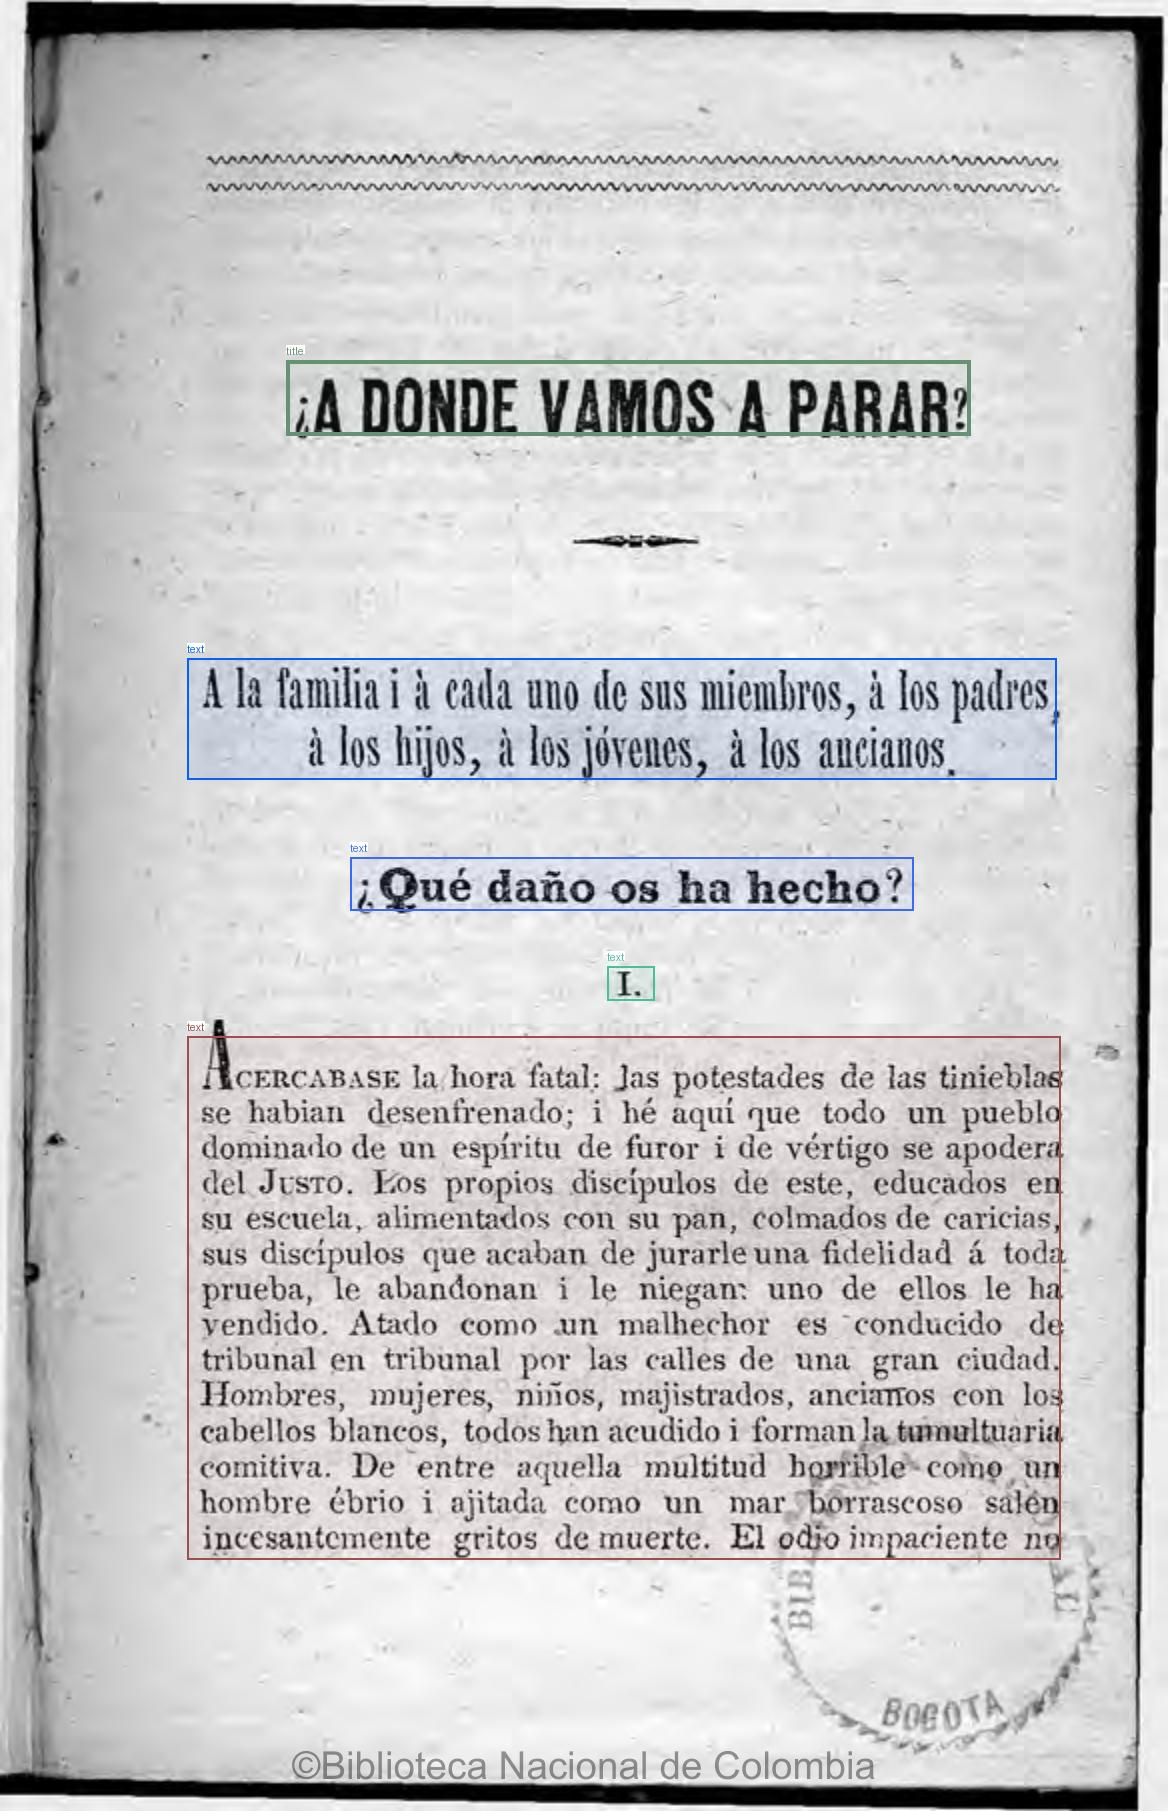

In [17]:
# display segmented image
Image(filename=f"{OCR_out}/result_with_boxes.jpg", width=600)

In [18]:
gt_page = [
        "# ¿A DONDE VAMOS A PARAR?",
        "A la familia i à cada uno de sus miembros, à los padres, à los hijos, à los jòvenes, à los ancianos.",
        "¿Qué daño os ha hecho?",
        "I.",
        "ACERCABASE la hora fatal: las potestades de las tinieblas se habian desenfrenado; i hé aquí que todo un pueblo dominado de un espíritu de furor i de vértigo se apodera del JUSTO. Los propios discípulos de este, educados en su escuela, alimentados con su pan, colmados de caricias, sus discípulos que acaban de jurarle una fidelidad á toda prueba, le abandonan i le niegan: uno de ellos le ha vendido. Atado como un melhechor es conducido de tribunal en tribunal por las calles de una gran ciudad. Hombres, mujeres, niños, majistrados, ancianos con los cabellos blancos, todos han acudido i forman la tumultuaria comitiva. De entre aquella multitud horrible como un hombre ébrio i ajitada como un mar borrascoso salen incesantemente gritos de muerte. El odio impaciente no"
        ]



In [19]:
with open(f"{OCR_out}/result.mmd", "r", encoding="utf-8") as f:
  ocr_page = f.read().split("\n")
  print(ocr_page)

['', '# ¿A DONDE VAMOS A PARAR? ', '', '', 'A la familia i á cada uno de sus miembros, á los padres, á los hijos, á los jóvenes, á los ancianos. ', '', '', '¿Qué daño os ha hecho? ', '', '', 'I. ', '', '', 'A CERCABASE la hora fatal: Jas potestades de las tinieblas se habian desenfrenado; i hé aquí que todo un pueblo dominado de un espíritu de furor i de vértigo se apodera del Juzro. Eos propios discípulos de este, educados en su escuela, alimentados con su pan, colmados de caricias, sus discípulos que acaban de jurarle una fidelidad á toda prueba, le abandonan i le niegan: uno de ellos le ha vendido. Atado como un malhechor es conducido de tribunal en tribunal por las calles de una gran ciudad. Hombres, mujeres, niños, majistrados, ancianos con los cabellos blancos, todos han acudido i forman la tumultaria comitiva. De entre aquella multitud horrible como un hombre ébrio i ajitada como un mar borrascoso salen incesantemente gritos de muerte. El oído impaciente no']


In [20]:
character_count = 0

for line in ocr_page:
  character_count += len(line)

print(f"Character count: {character_count}")

Character count: 924


## Character and Word Error Rate

In [21]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.8 MB/s eta 0:00:00a 0:00:01


In [22]:
import jiwer

In [23]:
ocr_page = [line for line in ocr_page if len(line) > 0]

In [24]:
for ref, hyp in zip(gt_page, ocr_page):
  print(ref)
  print(hyp)
  print(jiwer.wer(ref, hyp))
  print(jiwer.cer(ref, hyp))

# ¿A DONDE VAMOS A PARAR?
# ¿A DONDE VAMOS A PARAR? 
0.0
0.0
A la familia i à cada uno de sus miembros, à los padres, à los hijos, à los jòvenes, à los ancianos.
A la familia i á cada uno de sus miembros, á los padres, á los hijos, á los jóvenes, á los ancianos. 
0.2727272727272727
0.06
¿Qué daño os ha hecho?
¿Qué daño os ha hecho? 
0.0
0.0
I.
I. 
0.0
0.0
ACERCABASE la hora fatal: las potestades de las tinieblas se habian desenfrenado; i hé aquí que todo un pueblo dominado de un espíritu de furor i de vértigo se apodera del JUSTO. Los propios discípulos de este, educados en su escuela, alimentados con su pan, colmados de caricias, sus discípulos que acaban de jurarle una fidelidad á toda prueba, le abandonan i le niegan: uno de ellos le ha vendido. Atado como un melhechor es conducido de tribunal en tribunal por las calles de una gran ciudad. Hombres, mujeres, niños, majistrados, ancianos con los cabellos blancos, todos han acudido i forman la tumultuaria comitiva. De entre aquella mul

In [27]:
evaluation = {}

ln = 1
for ref, hyp in zip(gt_page, ocr_page):
  wer = jiwer.wer(ref, hyp)
  cer = jiwer.cer(ref, hyp)
  evaluation[ln] = {"text": ref, "wer": wer, "cer": cer}
  ln += 1
  
print(evaluation)

{1: {'text': '# ¿A DONDE VAMOS A PARAR?', 'wer': 0.0, 'cer': 0.0}, 2: {'text': 'A la familia i à cada uno de sus miembros, à los padres, à los hijos, à los jòvenes, à los ancianos.', 'wer': 0.2727272727272727, 'cer': 0.06}, 3: {'text': '¿Qué daño os ha hecho?', 'wer': 0.0, 'cer': 0.0}, 4: {'text': 'I.', 'wer': 0.0, 'cer': 0.0}, 5: {'text': 'ACERCABASE la hora fatal: las potestades de las tinieblas se habian desenfrenado; i hé aquí que todo un pueblo dominado de un espíritu de furor i de vértigo se apodera del JUSTO. Los propios discípulos de este, educados en su escuela, alimentados con su pan, colmados de caricias, sus discípulos que acaban de jurarle una fidelidad á toda prueba, le abandonan i le niegan: uno de ellos le ha vendido. Atado como un melhechor es conducido de tribunal en tribunal por las calles de una gran ciudad. Hombres, mujeres, niños, majistrados, ancianos con los cabellos blancos, todos han acudido i forman la tumultuaria comitiva. De entre aquella multitud horrible 

In [1]:
evaluation = {1: {'text': '# ¿A DONDE VAMOS A PARAR?', 'wer': 0.0, 'cer': 0.0}, 2: {'text': 'A la familia i à cada uno de sus miembros, à los padres, à los hijos, à los jòvenes, à los ancianos.', 'wer': 0.2727272727272727, 'cer': 0.06}, 3: {'text': '¿Qué daño os ha hecho?', 'wer': 0.0, 'cer': 0.0}, 4: {'text': 'I.', 'wer': 0.0, 'cer': 0.0}, 5: {'text': 'ACERCABASE la hora fatal: las potestades de las tinieblas se habian desenfrenado; i hé aquí que todo un pueblo dominado de un espíritu de furor i de vértigo se apodera del JUSTO. Los propios discípulos de este, educados en su escuela, alimentados con su pan, colmados de caricias, sus discípulos que acaban de jurarle una fidelidad á toda prueba, le abandonan i le niegan: uno de ellos le ha vendido. Atado como un melhechor es conducido de tribunal en tribunal por las calles de una gran ciudad. Hombres, mujeres, niños, majistrados, ancianos con los cabellos blancos, todos han acudido i forman la tumultuaria comitiva. De entre aquella multitud horrible como un hombre ébrio i ajitada como un mar borrascoso salen incesantemente gritos de muerte. El odio impaciente no', 'wer': 0.0625, 'cer': 0.014267185473411154}}

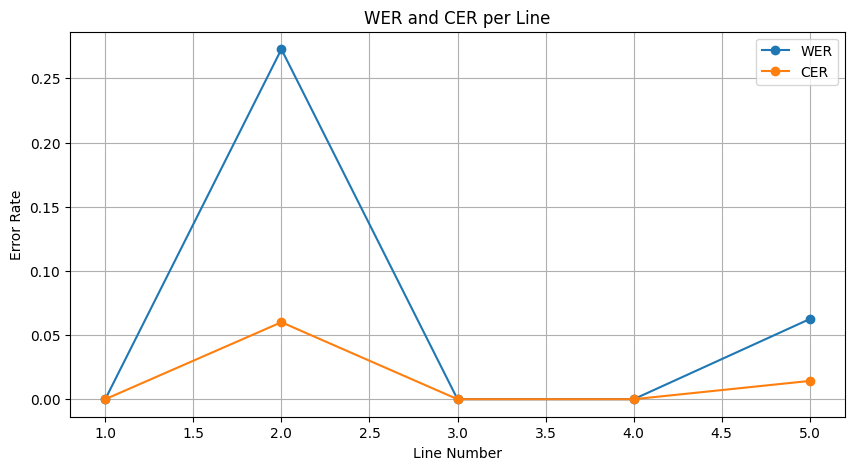

In [2]:
# plot WER and CER
import matplotlib.pyplot as plt
lines = list(evaluation.keys())
wer_values = [evaluation[ln]["wer"] for ln in lines]
cer_values = [evaluation[ln]["cer"] for ln in lines]
plt.figure(figsize=(10, 5))
plt.plot(lines, wer_values, marker='o', label='WER')
plt.plot(lines, cer_values, marker='o', label='CER')
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
plt.xlabel('Line Number')
plt.ylabel('Error Rate')
plt.title('WER and CER per Line')
plt.legend()
plt.grid()
plt.show()